# Final Evaluation of Synthetic Data

## Introduction

In this notebook, the evaluation of the synthetic datasets is carried out through three main steps. First, we load and preprocess both the original and synthetic datasets to ensure consistency and comparability. Next, we assess the predictive performance of the synthetic data by training three predictive models—logistic regression, decision tree, and random forest—and computing the mean and standard deviation of accuracy over multiple seeds. Then, a discriminator analysis is performed using a random forest to estimate how easily synthetic records can be distinguished from real ones. Finally, we calculate the Distance to Closest Record (DCR), which quantifies the similarity of each synthetic entry to its nearest counterpart in the original dataset. Each step provides complementary insights into the quality, realism, and utility of the generated data.

## 0 Imports

We import the necessary libraries for data handling, preprocessing, evaluation, and visualization. This includes pandas and numpy for data manipulation, scikit-learn for preprocessing, predictive modeling, and nearest-neighbor computations, matplotlib for plotting, and standard Python typing utilities for code clarity.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from typing import Dict, List

## Functions definitions:

The preprocess_dataset function is designed to prepare a tabular dataset for predictive evaluation. Its main steps are:

Type conversion - categorical features are explicitly converted to strings, while numerical features are coerced to numeric types to ensure consistent data handling.

Separation of features and target - the target column is separated from the input features.

Preprocessing pipeline - a ColumnTransformer is defined to handle different types of features:

Categorical features are imputed with the value "Unknown" for missing entries and one-hot encoded.

Numerical features are imputed using the mean of each column and standardized via StandardScaler.

Transformation - the input features are transformed using the pipeline.

The function returns the transformed feature matrix (X_transformed), the target vector (y), and the fitted preprocessor pipeline, which can be reused for consistent preprocessing on new data.

In [ ]:
def preprocess_dataset(df, target_column, categorical_features, numerical_features):
    df = df.copy()

    for col in categorical_features:
        df[col] = df[col].astype(str)  #force categorical as string

    for col in numerical_features:
        df[col] = pd.to_numeric(df[col], errors='coerce')  #ensure float

    X = df.drop(target_column, axis=1)
    y = df[target_column]

    preprocessor = ColumnTransformer(
        transformers=[
            ('categorical', Pipeline([
                ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
                ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
            ]), categorical_features),

            ('numerical', Pipeline([
                ('imputer', SimpleImputer(strategy='mean')),
                ('scaler', StandardScaler())
            ]), numerical_features)
        ])

    X_transformed = preprocessor.fit_transform(X)

    return X_transformed, y, preprocessor

In [ ]:
def apply_preprocessor(df, target_column, categorical_features, numerical_features, preprocessor):
    df = df.copy()

    for col in categorical_features:
        df[col] = df[col].astype(str)

    for col in numerical_features:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    X = df.drop(target_column, axis=1)
    y = df[target_column]

    X_transformed = preprocessor.transform(X)

    return X_transformed, y

These functions—train_and_evaluate_logistic_regression, train_and_evaluate_decision_tree, train_and_evaluate_random_forest, and train_and_evaluate_random_forest_discriminator—are designed to evaluate predictive performance on a given dataset under different modeling assumptions.

All functions follow a common evaluation pipeline:

Data splitting – the input features (X) and target labels (y) are split into training and testing sets using an 80/20 ratio, with a fixed random seed to ensure reproducibility.

Model instantiation and training – a predictive model is instantiated (logistic regression, decision tree, or random forest) and trained on the training subset.

Prediction and evaluation – the trained model is used to predict labels on the test set, and the accuracy score is computed as the proportion of correctly classified instances.

The first three functions focus on standard predictive performance, measuring how well each model generalizes to unseen data.

In contrast, train_and_evaluate_random_forest_discriminator implements a discriminative evaluation using a Random Forest classifier trained to distinguish between two classes (e.g., real vs. synthetic data). The resulting accuracy reflects the discriminator’s ability to separate the two distributions: values close to random guessing indicate high similarity between datasets, while higher accuracies suggest stronger distinguishability.

In [ ]:
def train_and_evaluate_logistic_regression(X, y, X_test_original, y_test_original, seed):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
  log_reg = LogisticRegression(random_state=seed, max_iter=1000)
  log_reg.fit(X_train, y_train)
  y_pred = log_reg.predict(X_test_original)

  return accuracy_score(y_test_original, y_pred)

In [ ]:
def train_and_evaluate_decision_tree(X, y, X_test_original, y_test_original, seed):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
  dt = DecisionTreeClassifier(random_state=seed)
  dt.fit(X_train, y_train)
  y_pred = dt.predict(X_test_original)

  return accuracy_score(y_test_original, y_pred)

In [ ]:
def train_and_evaluate_random_forest(X, y, X_test_original, y_test_original, seed):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
  rf = RandomForestClassifier(random_state=seed)
  rf.fit(X_train, y_train)
  y_pred = rf.predict(X_test_original)

  return accuracy_score(y_test_original, y_pred)

In [ ]:
def train_and_evaluate_random_forest_discriminator(X, y, seed):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
  rf = RandomForestClassifier(random_state=seed)
  rf.fit(X_train, y_train)
  y_pred = rf.predict(X_test)

  return accuracy_score(y_test, y_pred)

The create_results_table function is designed to summarize evaluation results in a clear and concise format. It takes a dictionary where keys represent model names or experiment identifiers and values are lists of numerical results (e.g., accuracy scores across multiple seeds). For each entry, the function computes the mean and standard deviation and formats them as "mean ± std". If no results are available for a given key, it returns "N/A". The output is a dictionary summarizing all entries, which can be easily converted to a pandas DataFrame for reporting or visualization.

In [ ]:
def create_results_table(results_dict: Dict[str, List[float]]) -> pd.DataFrame:
    summary_stats = {}
    for key, values in results_dict.items():
        if len(values) > 0:
            mean_val = np.mean(values)
            std_val = np.std(values, ddof=1) if len(values) > 1 else 0
            summary_stats[key] = f"{mean_val:.4f} ± {std_val:.4f}"
        else:
            summary_stats[key] = "N/A"

    return summary_stats

The organize_results_for_table function aggregates and formats the evaluation results of predictive models across both the German Credit Risk and Australian Credit Approval datasets. For each dataset, it considers three predictive models—logistic regression, decision tree, and random forest—and 10 data sources: the original data and the synthetic data generated by CopulaGAN, TVAE, CTGAN, Distil-GReaT, GReaT, ChatGPT-5, ClaudeAI, Copilot and Deepseek

The function performs the following steps:

Computes the mean and standard deviation for each list of accuracy results across multiple seeds, formatting them as "mean ± std"; if no results are available, "N/A" is returned.

Organizes the results into a structured table with a multi-level index, where the first level corresponds to the dataset and the second to the predictive model.

Assigns the data sources (original and synthetic generators) as column headers.

The output is a pandas DataFrame providing a clear summary of predictive performance across datasets, models, and generative approaches, ready for reporting or visualization.

Additionally, two utility functions are provided for working with this results table:

display_formatted_table(df) prints the DataFrame in a readable, clearly formatted layout with separators and a descriptive header.

save_results_table(df, filename) exports the DataFrame to a CSV file for external use or record keeping, providing feedback on the saved file location.

Together, these functions streamline the presentation, inspection, and storage of evaluation results.

In [ ]:
def organize_results_for_table(
    #German Credit results
    lr_german_original_results, lr_german_CopulaGAN_results, lr_german_TVAE_results,
    lr_german_CTGAN_results, lr_german_distil_GReaT_results, lr_german_GReaT_results,
    lr_german_GPT5_results, lr_german_Sonnet4_5_resutls, lr_german_Copilot_results, lr_german_Deepseek_results,
    dt_german_original_results, dt_german_CopulaGAN_results, dt_german_TVAE_results,
    dt_german_CTGAN_results, dt_german_distil_GReaT_results, dt_german_GReaT_results,
    dt_german_GPT5_results, dt_german_Sonnet4_5_resutls, dt_german_Copilot_results, dt_german_Deepseek_results,
    rf_german_original_results, rf_german_CopulaGAN_results, rf_german_TVAE_results,
    rf_german_CTGAN_results, rf_german_distil_GReaT_results, rf_german_GReaT_results,
    rf_german_GPT5_results, rf_german_Sonnet4_5_resutls, rf_german_Copilot_results, rf_german_Deepseek_results,

    #Australian Credit results
    lr_australian_original_results, lr_australian_CopulaGAN_results, lr_australian_TVAE_results,
    lr_australian_CTGAN_results, lr_australian_distil_GReaT_results, lr_australian_GReaT_results,
    lr_australian_GPT5_results, lr_australian_Sonnet4_5_resutls, lr_australian_Copilot_results, lr_australian_Deepseek_results,
    dt_australian_original_results, dt_australian_CopulaGAN_results, dt_australian_TVAE_results,
    dt_australian_CTGAN_results, dt_australian_distil_GReaT_results, dt_australian_GReaT_results,
    dt_australian_GPT5_results, dt_australian_Sonnet4_5_resutls, dt_australian_Copilot_results, dt_australian_Deepseek_results,
    rf_australian_original_results, rf_australian_CopulaGAN_results, rf_australian_TVAE_results,
    rf_australian_CTGAN_results, rf_australian_distil_GReaT_results, rf_australian_GReaT_results,
    rf_australian_GPT5_results, rf_australian_Sonnet4_5_resutls, rf_australian_Copilot_results, rf_australian_Deepseek_results

) -> pd.DataFrame:

    def calc_mean_std(values):
        if len(values) > 0:
            mean_val = np.mean(values)
            std_val = np.std(values, ddof=1) if len(values) > 1 else 0
            return f"{mean_val:.4f} ± {std_val:.4f}"
        return "N/A"

    datasets = [
        ('German Credit', [
            ('Logistic Regression', [lr_german_original_results, lr_german_CopulaGAN_results,
                                   lr_german_TVAE_results, lr_german_CTGAN_results,
                                   lr_german_distil_GReaT_results, lr_german_GReaT_results,
                                   lr_german_GPT5_results, lr_german_Sonnet4_5_results,
                                   lr_german_Copilot_results, lr_german_Deepseek_results]),
            ('Decision Tree', [dt_german_original_results, dt_german_CopulaGAN_results,
                             dt_german_TVAE_results, dt_german_CTGAN_results,
                             dt_german_distil_GReaT_results, dt_german_GReaT_results,
                             dt_german_GPT5_results, dt_german_Sonnet4_5_results,
                             dt_german_Copilot_results, dt_german_Deepseek_results]),
            ('Random Forest', [rf_german_original_results, rf_german_CopulaGAN_results,
                             rf_german_TVAE_results, rf_german_CTGAN_results,
                             rf_german_distil_GReaT_results, rf_german_GReaT_results,
                             rf_german_GPT5_results, rf_german_Sonnet4_5_results,
                             rf_german_Copilot_results, rf_german_Deepseek_results])
        ]),

        ('Australian Credit', [
            ('Logistic Regression', [lr_australian_original_results, lr_australian_CopulaGAN_results,
                                   lr_australian_TVAE_results, lr_australian_CTGAN_results,
                                   lr_australian_distil_GReaT_results, lr_australian_GReaT_results,
                                   lr_australian_GPT5_results, lr_australian_Sonnet4_5_results,
                                   lr_australian_Copilot_results, lr_australian_Deepseek_results]),
            ('Decision Tree', [dt_australian_original_results, dt_australian_CopulaGAN_results,
                             dt_australian_TVAE_results, dt_australian_CTGAN_results,
                             dt_australian_distil_GReaT_results, dt_australian_GReaT_results,
                             dt_australian_GPT5_results, dt_australian_Sonnet4_5_results,
                             dt_australian_Copilot_results, dt_australian_Deepseek_results]),
            ('Random Forest', [rf_australian_original_results, rf_australian_CopulaGAN_results,
                             rf_australian_TVAE_results, rf_australian_CTGAN_results,
                             rf_australian_distil_GReaT_results, rf_australian_GReaT_results,
                             rf_australian_GPT5_results, rf_australian_Sonnet4_5_results,
                             rf_australian_Copilot_results, rf_australian_Deepseek_results])
        ])
    ]

    generator_names = ['Original', 'CopulaGAN', 'TVAE', 'CTGAN', 'Distil-GReaT', 'GReaT', 'ChatGPT5', 'ClaudeAI', 'Copilot', 'Deepseek']

    rows = []
    index_tuples = []

    for dataset_name, models in datasets:
        for model_name, results_lists in models:
            row = []
            for results_list in results_lists:
                row.append(calc_mean_std(results_list))
            rows.append(row)
            index_tuples.append((dataset_name, model_name))

    multi_index = pd.MultiIndex.from_tuples(index_tuples, names=['Dataset', 'Model'])
    df = pd.DataFrame(rows, index=multi_index, columns=generator_names)

    return df

In [ ]:
def display_formatted_table(df: pd.DataFrame):
    print("=== RESULTS TABLE: ACCURACY (Mean ± Std) ===")
    print("=" * 100)
    print(df.to_string())
    print("=" * 100)

    return df

In [ ]:
def save_results_table(df: pd.DataFrame, filename: str = "results_table.csv"):
    df.to_csv(filename)
    print(f"Table saved in: {filename}")

The organize_discriminator_results_for_table function formats the results of the discriminator analysis, which measures how well a random forest can distinguish synthetic records from original ones. The function considers both the German Credit Risk and Australian Credit Approval datasets, and for each dataset it evaluates the synthetic data generated by five models and the two LLMs: CopulaGAN, TVAE, CTGAN, Distil-GReaT, GReaT, ChatGPT, ClaudeAI, Copilot and Deepseek.

The procedure is as follows:

For each generator, the function calculates the mean and standard deviation of the discriminator accuracy across multiple seeds, formatting them as "mean ± std"; if no results are available, "N/A" is returned.

Results are organized into a multi-index DataFrame, with datasets as the first index level and "Discriminator" as the second, while the generators form the columns.

The resulting DataFrame provides a clear summary of discriminator performance, facilitating comparison of how distinguishable synthetic data is across different generative models and datasets.

In [ ]:
def organize_discriminator_results_for_table(
    #German Credit
    german_CopulaGAN_discriminator_results, german_TVAE_discriminator_results,
    german_CTGAN_discriminator_results, german_distil_GReaT_discriminator_results,
    german_GReaT_discriminator_results, german_GPT5_discriminator_results, german_Sonnet4_5_discriminator_results,
    german_Copilot_discriminator_results, german_Deepseek_discriminator_results,

    #Australian Credit
    australian_CopulaGAN_discriminator_results, australian_TVAE_discriminator_results,
    australian_CTGAN_discriminator_results, australian_distil_GReaT_discriminator_results,
    australian_GReaT_discriminator_results, australian_GPT5_discriminator_results, australian_Sonnet4_5_discriminator_results,
    australian_Copilot_discriminator_results, australian_Deepseek_discriminator_results
) -> pd.DataFrame:

    def calc_mean_std(values):
        if len(values) > 0:
            mean_val = np.mean(values)
            std_val = np.std(values, ddof=1) if len(values) > 1 else 0
            return f"{mean_val:.4f} ± {std_val:.4f}"
        return "N/A"


    datasets = [
        ('German Credit', [
            ('Discriminator', [german_CopulaGAN_discriminator_results, german_TVAE_discriminator_results,
                              german_CTGAN_discriminator_results, german_distil_GReaT_discriminator_results,
                              german_GReaT_discriminator_results, german_GPT5_discriminator_results, german_Sonnet4_5_discriminator_results,
                              german_Copilot_discriminator_results, german_Deepseek_discriminator_results])
        ]),
        ('Australian Credit', [
            ('Discriminator', [australian_CopulaGAN_discriminator_results, australian_TVAE_discriminator_results,
                              australian_CTGAN_discriminator_results, australian_distil_GReaT_discriminator_results,
                              australian_GReaT_discriminator_results, australian_GPT5_discriminator_results, australian_Sonnet4_5_discriminator_results,
                              australian_Copilot_discriminator_results, australian_Deepseek_discriminator_results])
        ])
    ]

    generator_names = ['CopulaGAN', 'TVAE', 'CTGAN', 'Distil-GReaT', 'GReaT', 'ChatGPT5', 'ClaudeAI', 'Copilot', 'Deepseek']


    rows = []
    index_tuples = []

    for dataset_name, models in datasets:
        for model_name, results_lists in models:
            row = [calc_mean_std(results) for results in results_lists]
            rows.append(row)
            index_tuples.append((dataset_name, model_name))

    multi_index = pd.MultiIndex.from_tuples(index_tuples, names=['Dataset', 'Model'])
    df = pd.DataFrame(rows, index=multi_index, columns=generator_names)

    return df

The compute_dcr function calculates the Distance to Closest Record (DCR) between a synthetic dataset and its corresponding real dataset. Using a nearest neighbors approach with Euclidean distance, the function finds, for each synthetic record, the closest record in the original dataset and computes the distance. The output is a one-dimensional array of distances, providing a quantitative measure of similarity between synthetic and real records.

In [ ]:
def compute_dcr(real_data, synthetic_data):
    #Compute Distance to Closest Record (DCR) values
    nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
    nn.fit(real_data)
    distances, _ = nn.kneighbors(synthetic_data)
    return distances.flatten()

## 1 Dataset loading

In this section, all relevant datasets are loaded from CSV files and stored as pandas DataFrames for subsequent analysis. This includes the original German Credit Risk and Australian Credit Approval datasets, as well as multiple synthetic counterparts generated by various models.

For the German Credit dataset, the first column—corresponding to an index or auxiliary identifier—is explicitly removed from the original dataset and most synthetic datasets to ensure schema consistency across all data sources. However, this removal step is omitted for the synthetic datasets generated by Copilot and Deepseek, as the baseline data provided to these models for generation had already been stripped of this identifier.

Furthermore, categorical and numerical feature sets are explicitly defined for each dataset. This feature partitioning is subsequently leveraged during preprocessing to enforce consistent data types and transformations across both original and synthetic data, thereby enabling a fair and controlled evaluation of downstream predictive models.

#### German Credist Risk

In [ ]:
#Load German Credit Risk
german_df = pd.read_csv('german_credit_risk.csv')

In [ ]:
german_df = german_df.drop(german_df.columns[0], axis=1)

german_categorical_features = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
german_numerical_features = ['Age', 'Credit amount', 'Duration']

In [ ]:
synthetic_german_df_CopulaGan = pd.read_csv('synthetic_data_german_CopulaGAN.csv')
synthetic_german_df_TVAE = pd.read_csv('synthetic_data_german_TVAE.csv')
synthetic_german_df_CTGAN = pd.read_csv('synthetic_data_german_CTGAN.csv')
synthetic_german_df_distil_GReaT = pd.read_csv('synthetic_data_german_distil_GReaT.csv')
synthetic_german_df_GReaT = pd.read_csv('synthetic_data_german_GReaT.csv')

In [ ]:
synthetic_german_df_GPT5 = pd.read_csv('synthetic_data_german_GPT5.csv')
synthetic_german_df_GPT5 = synthetic_german_df_GPT5.drop(synthetic_german_df_GPT5.columns[0], axis=1)

synthetic_german_df_Sonnet4_5 = pd.read_csv('synthetic_data_german_Sonnet4_5.csv')
synthetic_german_df_Sonnet4_5 = synthetic_german_df_Sonnet4_5.drop(synthetic_german_df_Sonnet4_5.columns[0], axis=1)

synthetic_german_df_Copilot = pd.read_csv('synthetic_data_german_Copilot.csv')
synthetic_german_df_Deepseek = pd.read_csv('synthetic_data_german_Deepseek.csv')

#### Australian Credit Approval

In [ ]:
#Load Australian Credit Approval
australian_df = pd.read_csv('australian_credit_approval.csv')

In [ ]:
australian_categorical_features = ['A1', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11', 'A12']
australian_numerical_features = ['A2', 'A3', 'A7', 'A10', 'A13', 'A14']

In [ ]:
synthetic_australian_df_CopulaGan = pd.read_csv('synthetic_data_australian_CopulaGAN.csv')
synthetic_australian_df_TVAE = pd.read_csv('synthetic_data_australian_TVAE.csv')
synthetic_australian_df_CTGAN = pd.read_csv('synthetic_data_australian_CTGAN.csv')
synthetic_australian_df_distil_GReaT = pd.read_csv('synthetic_data_australian_distil_GReaT.csv')
synthetic_australian_df_GReaT = pd.read_csv('synthetic_data_australian_GReaT.csv')

In [ ]:
synthetic_australian_df_GPT5 = pd.read_csv('synthetic_data_australian_GPT5.csv')
synthetic_australian_df_Sonnet4_5 = pd.read_csv('synthetic_data_australian_Sonnet4_5.csv')
synthetic_australian_df_Copilot = pd.read_csv('synthetic_data_australian_Copilot.csv')
synthetic_australian_df_Deepseek = pd.read_csv('synthetic_data_australian_Deepseek.csv')

## 2 Preprocessing

In this phase, we preprocess both the original and synthetic datasets using the previously defined preprocess_dataset function. This step ensures that categorical and numerical features are correctly encoded and scaled, and that missing values are appropriately handled. The output consists of the transformed feature matrices, the target vectors, and the fitted preprocessing pipelines, which will be consistently used for all subsequent predictive evaluations.

### German

In [ ]:
X_german, y_german, preprocessor_german = preprocess_dataset(german_df, 'Risk', german_categorical_features, german_numerical_features)

In [ ]:
X_german_CopulaGAN, y_german_CopulaGAN = apply_preprocessor(synthetic_german_df_CopulaGan, 'Risk', german_categorical_features, german_numerical_features, preprocessor_german)

In [ ]:
X_german_TVAE, y_german_TVAE = apply_preprocessor(synthetic_german_df_TVAE, 'Risk', german_categorical_features, german_numerical_features, preprocessor_german)

In [ ]:
X_german_CTGAN, y_german_CTGAN = apply_preprocessor(synthetic_german_df_CTGAN, 'Risk', german_categorical_features, german_numerical_features, preprocessor_german)

In [ ]:
X_german_distil_GReaT, y_german_distil_GReaT = apply_preprocessor(synthetic_german_df_distil_GReaT, 'Risk', german_categorical_features, german_numerical_features, preprocessor_german)

In [ ]:
X_german_GReaT, y_german_GReaT = apply_preprocessor(synthetic_german_df_GReaT, 'Risk', german_categorical_features, german_numerical_features, preprocessor_german)

In [ ]:
X_german_GPT5, y_german_GPT5 = apply_preprocessor(synthetic_german_df_GPT5, 'Risk', german_categorical_features, german_numerical_features, preprocessor_german)

In [ ]:
X_german_Sonnet4_5, y_german_Sonnet4_5 = apply_preprocessor(synthetic_german_df_Sonnet4_5, 'Risk', german_categorical_features, german_numerical_features, preprocessor_german)

In [ ]:
X_german_Copilot, y_german_Copilot = apply_preprocessor(synthetic_german_df_Copilot, 'Risk', german_categorical_features, german_numerical_features, preprocessor_german)

In [ ]:
X_german_Deepseek, y_german_Deepseek = apply_preprocessor(synthetic_german_df_Deepseek, 'Risk', german_categorical_features, german_numerical_features, preprocessor_german)

### Australian

In [ ]:
X_australian, y_australian, preprocessor_australian = preprocess_dataset(australian_df,'Class', australian_numerical_features, australian_categorical_features)

In [ ]:
X_australian_CopulaGAN, y_australian_CopulaGAN = apply_preprocessor(synthetic_australian_df_CopulaGan, 'Class', australian_numerical_features, australian_categorical_features, preprocessor_australian)

In [ ]:
X_australian_TVAE, y_australian_TVAE = apply_preprocessor(synthetic_australian_df_TVAE, 'Class', australian_numerical_features, australian_categorical_features, preprocessor_australian)

In [ ]:
X_australian_CTGAN, y_australian_CTGAN = apply_preprocessor(synthetic_australian_df_CTGAN, 'Class', australian_numerical_features, australian_categorical_features, preprocessor_australian)

In [ ]:
X_australian_distil_GReaT, y_australian_distil_GReaT = apply_preprocessor(synthetic_australian_df_distil_GReaT, 'Class', australian_numerical_features, australian_categorical_features, preprocessor_australian)

In [ ]:
X_australian_GReaT, y_australian_GReaT = apply_preprocessor(synthetic_australian_df_GReaT, 'Class', australian_numerical_features, australian_categorical_features, preprocessor_australian)

In [ ]:
X_australian_GPT5, y_australian_GPT5 = apply_preprocessor(synthetic_australian_df_GPT5, 'Class', australian_numerical_features, australian_categorical_features, preprocessor_australian)

In [ ]:
X_australian_Sonnet4_5, y_australian_Sonnet4_5 = apply_preprocessor(synthetic_australian_df_Sonnet4_5, 'Class', australian_numerical_features, australian_categorical_features, preprocessor_australian)

In [ ]:
X_australian_Copilot, y_australian_Copilot = apply_preprocessor(synthetic_australian_df_Copilot, 'Class', australian_numerical_features, australian_categorical_features, preprocessor_australian)

In [ ]:
X_australian_Deepseek, y_australian_Deepseek = apply_preprocessor(synthetic_australian_df_Deepseek, 'Class', australian_numerical_features, australian_categorical_features, preprocessor_australian)

## 3 Evaluation

In this section, we perform predictive evaluation of the synthetic datasets. First, we initialize the necessary variables to store results and define the random seeds for reproducibility. We then train and evaluate three predictive models—logistic regression, decision tree, and random forest—on both the original and synthetic datasets. Finally, the results from all models and datasets are collected and summarized in a structured table, providing a comprehensive overview of predictive performance for subsequent analysis.

### Initialization

In [ ]:
#We consider five different seeds
RANDOM_SEEDS = [42, 43, 44, 45, 46]

In [ ]:
lr_german_original_results = []
lr_german_CopulaGAN_results = []
lr_german_TVAE_results = []
lr_german_CTGAN_results = []
lr_german_distil_GReaT_results = []
lr_german_GReaT_results = []
lr_german_GPT5_results = []
lr_german_Sonnet4_5_results = []
lr_german_Copilot_results = []
lr_german_Deepseek_results = []
dt_german_original_results = []
dt_german_CopulaGAN_results = []
dt_german_TVAE_results = []
dt_german_CTGAN_results = []
dt_german_distil_GReaT_results = []
dt_german_GReaT_results = []
dt_german_GPT5_results = []
dt_german_Sonnet4_5_results = []
dt_german_Copilot_results = []
dt_german_Deepseek_results = []
rf_german_original_results = []
rf_german_CopulaGAN_results = []
rf_german_TVAE_results = []
rf_german_CTGAN_results = []
rf_german_distil_GReaT_results = []
rf_german_GReaT_results = []
rf_german_GPT5_results = []
rf_german_Sonnet4_5_results = []
rf_german_Copilot_results = []
rf_german_Deepseek_results = []

In [ ]:
lr_australian_original_results = []
lr_australian_CopulaGAN_results = []
lr_australian_TVAE_results = []
lr_australian_CTGAN_results = []
lr_australian_distil_GReaT_results = []
lr_australian_GReaT_results = []
lr_australian_GPT5_results = []
lr_australian_Sonnet4_5_results = []
lr_australian_Copilot_results = []
lr_australian_Deepseek_results = []
dt_australian_original_results = []
dt_australian_CopulaGAN_results = []
dt_australian_TVAE_results = []
dt_australian_CTGAN_results = []
dt_australian_distil_GReaT_results = []
dt_australian_GReaT_results = []
dt_australian_GPT5_results = []
dt_australian_Sonnet4_5_results = []
dt_australian_Copilot_results = []
dt_australian_Deepseek_results = []
rf_australian_original_results = []
rf_australian_CopulaGAN_results = []
rf_australian_TVAE_results = []
rf_australian_CTGAN_results = []
rf_australian_distil_GReaT_results = []
rf_australian_GReaT_results = []
rf_australian_GPT5_results = []
rf_australian_Sonnet4_5_results = []
rf_australian_Copilot_results = []
rf_australian_Deepseek_results = []

### Logistic Regression

Now we start computing the classifiers' results for each dataset.

#### Original datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  log_reg_german = LogisticRegression(random_state=seed, max_iter=1000)
  log_reg_german.fit(X_train_german, y_train_german)
  y_pred_german = log_reg_german.predict(X_test_german)
  lr_german_original_results.append(accuracy_score(y_test_german, y_pred_german))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  log_reg_australian = LogisticRegression(random_state=seed, max_iter=1000)
  log_reg_australian.fit(X_train_australian, y_train_australian)
  y_pred_australian = log_reg_australian.predict(X_test_australian)
  lr_australian_original_results.append(accuracy_score(y_test_australian, y_pred_australian))

#### CopulaGAN datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  lr_german_CopulaGAN_results.append(train_and_evaluate_logistic_regression(X_german_CopulaGAN, y_german_CopulaGAN, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  lr_australian_CopulaGAN_results.append(train_and_evaluate_logistic_regression(X_australian_CopulaGAN, y_australian_CopulaGAN, X_test_australian, y_test_australian, seed))

#### TVAE datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  lr_german_TVAE_results.append(train_and_evaluate_logistic_regression(X_german_TVAE, y_german_TVAE, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  lr_australian_TVAE_results.append(train_and_evaluate_logistic_regression(X_australian_TVAE, y_australian_TVAE, X_test_australian, y_test_australian, seed))

#### CTGAN datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  lr_german_CTGAN_results.append(train_and_evaluate_logistic_regression(X_german_CTGAN, y_german_CTGAN, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  lr_australian_CTGAN_results.append(train_and_evaluate_logistic_regression(X_australian_CTGAN, y_australian_CTGAN, X_test_australian, y_test_australian, seed))

#### Distil-GReaT datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  lr_german_distil_GReaT_results.append(train_and_evaluate_logistic_regression(X_german_distil_GReaT, y_german_distil_GReaT, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  lr_australian_distil_GReaT_results.append(train_and_evaluate_logistic_regression(X_australian_distil_GReaT, y_australian_distil_GReaT, X_test_australian, y_test_australian, seed))

#### GReaT datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  lr_german_GReaT_results.append(train_and_evaluate_logistic_regression(X_german_GReaT, y_german_GReaT, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  lr_australian_GReaT_results.append(train_and_evaluate_logistic_regression(X_australian_GReaT, y_australian_GReaT, X_test_australian, y_test_australian, seed))

#### ChatGPT5 datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  lr_german_GPT5_results.append(train_and_evaluate_logistic_regression(X_german_GPT5, y_german_GPT5, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  lr_australian_GPT5_results.append(train_and_evaluate_logistic_regression(X_australian_GPT5, y_australian_GPT5, X_test_australian, y_test_australian, seed))

#### ClaudeAI datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  lr_german_Sonnet4_5_results.append(train_and_evaluate_logistic_regression(X_german_Sonnet4_5, y_german_Sonnet4_5, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  lr_australian_Sonnet4_5_results.append(train_and_evaluate_logistic_regression(X_australian_Sonnet4_5, y_australian_Sonnet4_5, X_test_australian, y_test_australian, seed))

####Copilot datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  lr_german_Copilot_results.append(train_and_evaluate_logistic_regression(X_german_Copilot, y_german_Copilot, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  lr_australian_Copilot_results.append(train_and_evaluate_logistic_regression(X_australian_Copilot, y_australian_Copilot, X_test_australian, y_test_australian, seed))

####Deepseek datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  lr_german_Deepseek_results.append(train_and_evaluate_logistic_regression(X_german_Deepseek, y_german_Deepseek, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  lr_australian_Deepseek_results.append(train_and_evaluate_logistic_regression(X_australian_Deepseek, y_australian_Deepseek, X_test_australian, y_test_australian, seed))

### Decision Tree

#### Original dataset

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  dt_german = DecisionTreeClassifier(random_state=seed)
  dt_german.fit(X_train_german, y_train_german)
  y_pred_german = dt_german.predict(X_test_german)
  dt_german_original_results.append(accuracy_score(y_test_german, y_pred_german))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  dt_australian = DecisionTreeClassifier(random_state=seed)
  dt_australian.fit(X_train_australian, y_train_australian)
  y_pred_australian = dt_australian.predict(X_test_australian)

  dt_australian_original_results.append(accuracy_score(y_test_australian, y_pred_australian))

#### CopulaGAN datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  dt_german_CopulaGAN_results.append(train_and_evaluate_decision_tree(X_german_CopulaGAN, y_german_CopulaGAN, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  dt_australian_CopulaGAN_results.append(train_and_evaluate_decision_tree(X_australian_CopulaGAN, y_australian_CopulaGAN, X_test_australian, y_test_australian, seed))

#### TVAE datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  dt_german_TVAE_results.append(train_and_evaluate_decision_tree(X_german_TVAE, y_german_TVAE, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  dt_australian_TVAE_results.append(train_and_evaluate_decision_tree(X_australian_TVAE, y_australian_TVAE, X_test_australian, y_test_australian, seed))

#### CTGAN datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  dt_german_CTGAN_results.append(train_and_evaluate_decision_tree(X_german_CTGAN, y_german_CTGAN, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  dt_australian_CTGAN_results.append(train_and_evaluate_decision_tree(X_australian_CTGAN, y_australian_CTGAN, X_test_australian, y_test_australian, seed))

#### Distil-GReaT datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  dt_german_distil_GReaT_results.append(train_and_evaluate_decision_tree(X_german_distil_GReaT, y_german_distil_GReaT, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  dt_australian_distil_GReaT_results.append(train_and_evaluate_decision_tree(X_australian_distil_GReaT, y_australian_distil_GReaT, X_test_australian, y_test_australian, seed))

#### GReaT datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  dt_german_GReaT_results.append(train_and_evaluate_decision_tree(X_german_GReaT, y_german_GReaT, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  dt_australian_GReaT_results.append(train_and_evaluate_decision_tree(X_australian_GReaT, y_australian_GReaT, X_test_australian, y_test_australian, seed))

#### ChatGPT5 datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  dt_german_GPT5_results.append(train_and_evaluate_decision_tree(X_german_GPT5, y_german_GPT5, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  dt_australian_GPT5_results.append(train_and_evaluate_decision_tree(X_australian_GPT5, y_australian_GPT5, X_test_australian, y_test_australian, seed))

#### ClaudeAI datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  dt_german_Sonnet4_5_results.append(train_and_evaluate_decision_tree(X_german_Sonnet4_5, y_german_Sonnet4_5, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  dt_australian_Sonnet4_5_results.append(train_and_evaluate_decision_tree(X_australian_Sonnet4_5, y_australian_Sonnet4_5, X_test_australian, y_test_australian, seed))

####Copilot datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  dt_german_Copilot_results.append(train_and_evaluate_decision_tree(X_german_Copilot, y_german_Copilot, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  dt_australian_Copilot_results.append(train_and_evaluate_decision_tree(X_australian_Copilot, y_australian_Copilot, X_test_australian, y_test_australian, seed))

####Deepseek datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  dt_german_Deepseek_results.append(train_and_evaluate_decision_tree(X_german_Deepseek, y_german_Deepseek, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  dt_australian_Deepseek_results.append(train_and_evaluate_decision_tree(X_australian_Deepseek, y_australian_Deepseek, X_test_australian, y_test_australian, seed))

### Random Forest

#### Original datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  rf_german = RandomForestClassifier(random_state=seed)
  rf_german.fit(X_train_german, y_train_german)
  y_pred_german = rf_german.predict(X_test_german)
  rf_german_original_results.append(accuracy_score(y_test_german, y_pred_german))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  rf_australian = RandomForestClassifier(random_state=seed)
  rf_australian.fit(X_train_australian, y_train_australian)
  y_pred_australian = rf_australian.predict(X_test_australian)
  rf_australian_original_results.append(accuracy_score(y_test_australian, y_pred_australian))

#### CopulaGAN datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  rf_german_CopulaGAN_results.append(train_and_evaluate_random_forest(X_german_CopulaGAN, y_german_CopulaGAN, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  rf_australian_CopulaGAN_results.append(train_and_evaluate_random_forest(X_australian_CopulaGAN, y_australian_CopulaGAN, X_test_australian, y_test_australian, seed))

#### TVAE datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  rf_german_TVAE_results.append(train_and_evaluate_random_forest(X_german_TVAE, y_german_TVAE, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  rf_australian_TVAE_results.append(train_and_evaluate_random_forest(X_australian_TVAE, y_australian_TVAE, X_test_australian, y_test_australian, seed))

#### CTGAN datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  rf_german_CTGAN_results.append(train_and_evaluate_random_forest(X_german_CTGAN, y_german_CTGAN, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  rf_australian_CTGAN_results.append(train_and_evaluate_random_forest(X_australian_CTGAN, y_australian_CTGAN, X_test_australian, y_test_australian, seed))

#### Distil-GReaT datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  rf_german_distil_GReaT_results.append(train_and_evaluate_random_forest(X_german_distil_GReaT, y_german_distil_GReaT, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  rf_australian_distil_GReaT_results.append(train_and_evaluate_random_forest(X_australian_distil_GReaT, y_australian_distil_GReaT, X_test_australian, y_test_australian, seed))

#### GReaT datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  rf_german_GReaT_results.append(train_and_evaluate_random_forest(X_german_GReaT, y_german_GReaT, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  rf_australian_GReaT_results.append(train_and_evaluate_random_forest(X_australian_GReaT, y_australian_GReaT, X_test_australian, y_test_australian, seed))

#### ChatGPT5 datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  rf_german_GPT5_results.append(train_and_evaluate_random_forest(X_german_GPT5, y_german_GPT5, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  rf_australian_GPT5_results.append(train_and_evaluate_random_forest(X_australian_GPT5, y_australian_GPT5, X_test_australian, y_test_australian, seed))

#### ClaudeAI datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  rf_german_Sonnet4_5_results.append(train_and_evaluate_random_forest(X_german_Sonnet4_5, y_german_Sonnet4_5, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  rf_australian_Sonnet4_5_results.append(train_and_evaluate_random_forest(X_australian_Sonnet4_5, y_australian_Sonnet4_5, X_test_australian, y_test_australian, seed))

####Copilot datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  rf_german_Copilot_results.append(train_and_evaluate_random_forest(X_german_Copilot, y_german_Copilot, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  rf_australian_Copilot_results.append(train_and_evaluate_random_forest(X_australian_Copilot, y_australian_Copilot, X_test_australian, y_test_australian, seed))

####Deepseek datasets

In [ ]:
X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
rf_german_Deepseek_results.append(train_and_evaluate_random_forest(X_german_Deepseek, y_german_Deepseek, X_test_german, y_test_german, seed))

X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
rf_australian_Deepseek_results.append(train_and_evaluate_random_forest(X_australian_Deepseek, y_australian_Deepseek, X_test_australian, y_test_australian, seed))

### Results

At this stage, we organize the collected results into a structured table that summarizes the predictive performance across datasets, models, and generators. The table is then displayed in a readable format and also saved as a CSV file for future reference and analysis.

In [ ]:
results_table = organize_results_for_table(
    #German Credit results
    lr_german_original_results, lr_german_CopulaGAN_results, lr_german_TVAE_results,
    lr_german_CTGAN_results, lr_german_distil_GReaT_results, lr_german_GReaT_results,
    lr_german_GPT5_results, lr_german_Sonnet4_5_results, lr_german_Copilot_results, lr_german_Deepseek_results,
    dt_german_original_results, dt_german_CopulaGAN_results, dt_german_TVAE_results,
    dt_german_CTGAN_results, dt_german_distil_GReaT_results, dt_german_GReaT_results,
    dt_german_GPT5_results, dt_german_Sonnet4_5_results, dt_german_Copilot_results, dt_german_Deepseek_results,
    rf_german_original_results, rf_german_CopulaGAN_results, rf_german_TVAE_results,
    rf_german_CTGAN_results, rf_german_distil_GReaT_results, rf_german_GReaT_results,
    rf_german_GPT5_results, rf_german_Sonnet4_5_results, rf_german_Copilot_results, rf_german_Deepseek_results,

    #Australian Credit results
    lr_australian_original_results, lr_australian_CopulaGAN_results, lr_australian_TVAE_results,
    lr_australian_CTGAN_results, lr_australian_distil_GReaT_results, lr_australian_GReaT_results,
    lr_australian_GPT5_results, lr_australian_Sonnet4_5_results, lr_australian_Copilot_results, lr_australian_Deepseek_results,
    dt_australian_original_results, dt_australian_CopulaGAN_results, dt_australian_TVAE_results,
    dt_australian_CTGAN_results, dt_australian_distil_GReaT_results, dt_australian_GReaT_results,
    dt_australian_GPT5_results, dt_australian_Sonnet4_5_results, dt_australian_Copilot_results, dt_australian_Deepseek_results,
    rf_australian_original_results, rf_australian_CopulaGAN_results, rf_australian_TVAE_results,
    rf_australian_CTGAN_results, rf_australian_distil_GReaT_results, rf_australian_GReaT_results,
    rf_australian_GPT5_results, rf_australian_Sonnet4_5_results, rf_australian_Copilot_results, rf_australian_Deepseek_results
)

display_formatted_table(results_table)

save_results_table(results_table, "synthetic_data_results.csv")

display(results_table)

=== RESULTS TABLE: ACCURACY (Mean ± Std) ===
                                              Original        CopulaGAN             TVAE            CTGAN     Distil-GReaT            GReaT         ChatGPT5         ClaudeAI          Copilot         Deepseek
Dataset           Model                                                                                                                                                                                        
German Credit     Logistic Regression  0.7390 ± 0.0185  0.4970 ± 0.0616  0.7380 ± 0.0291  0.6980 ± 0.0160  0.6960 ± 0.0210  0.6950 ± 0.0146  0.7240 ± 0.0082  0.6860 ± 0.0279  0.6600 ± 0.0242  0.7390 ± 0.0185
                  Decision Tree        0.6610 ± 0.0185  0.4630 ± 0.0313  0.7020 ± 0.0275  0.6110 ± 0.0266  0.5170 ± 0.0603  0.5320 ± 0.0365  0.6640 ± 0.0512  0.5760 ± 0.0503  0.6050 ± 0.0539  0.6610 ± 0.0185
                  Random Forest        0.7520 ± 0.0233  0.5070 ± 0.0282  0.7160 ± 0.0182  0.6920 ± 0.0182  0.6620 ± 0.0385 

Original        CopulaGAN  \
Dataset           Model                                                   
German Credit     Logistic Regression  0.7390 ± 0.0185  0.4970 ± 0.0616   
                  Decision Tree        0.6610 ± 0.0185  0.4630 ± 0.0313   
                  Random Forest        0.7520 ± 0.0233  0.5070 ± 0.0282   
Australian Credit Logistic Regression  0.8522 ± 0.0121  0.5681 ± 0.0357   
                  Decision Tree        0.8333 ± 0.0281  0.5420 ± 0.0578   
                  Random Forest        0.8551 ± 0.0229  0.5304 ± 0.0374   

                                                  TVAE            CTGAN  \
Dataset           Model                                                   
German Credit     Logistic Regression  0.7380 ± 0.0291  0.6980 ± 0.0160   
                  Decision Tree        0.7020 ± 0.0275  0.6110 ± 0.0266   
                  Random Forest        0.7160 ± 0.0182  0.6920 ± 0.0182   
Australian Credit Logistic Regression  0.8159 ± 0.0254  0.5377 ± 0.0663   
                  Decision Tree        0.7754 ± 0.0089  0.4551 ± 0.0585   
                  Random Forest        0.7710 ± 0.0141  0.4406 ± 0.0609   

                                          Distil-GReaT            GReaT  \
Dataset           Model                                                   
German Credit     Logistic Regression  0.6960 ± 0.0210  0.6950 ± 0.0146   
                  Decision Tree        0.5170 ± 0.0603  0.5320 ± 0.0365   
                  Random Forest        0.6620 ± 0.0385  0.6910 ± 0.0164   
Australian Credit Logistic Regression  0.8391 ± 0.0119  0.8522 ± 0.0175   
                  Decision Tree        0.7971 ± 0.0211  0.8000 ± 0.0175   
                  Random Forest        0.8406 ± 0.0051  0.8536 ± 0.0130   

                                              ChatGPT5         ClaudeAI  \
Dataset           Model                                                   
German Credit     Logistic Regression  0.7240 ± 0.0082  0.6860 ± 0.0279   
                  Decision Tree        0.6640 ± 0.0512  0.5760 ± 0.0503   
                  Random Forest        0.7070 ± 0.0168  0.6590 ± 0.0152   
Australian Credit Logistic Regression  0.8812 ± 0.0293  0.5942 ± 0.0423   
                  Decision Tree        0.8043 ± 0.0089  0.5449 ± 0.0711   
                  Random Forest        0.8725 ± 0.0209  0.5203 ± 0.0451   

                                               Copilot         Deepseek  
Dataset           Model                                                  
German Credit     Logistic Regression  0.6600 ± 0.0242  0.7390 ± 0.0185  
                  Decision Tree        0.6050 ± 0.0539  0.6610 ± 0.0185  
                  Random Forest        0.6690 ± 0.0167  0.7600 ± 0.0000  
Australian Credit Logistic Regression  0.8536 ± 0.0226  0.8507 ± 0.0264  
                  Decision Tree        0.8478 ± 0.0223  0.7942 ± 0.0375  
                  Random Forest        0.8391 ± 0.0237  0.8333 ± 0.0000

The accuracy results reveal dataset-dependent differences in how effectively synthetic data preserve predictive utility across classifiers and generative models.

For the German Credit dataset, the original data generally provide the strongest performance, indicating that the underlying feature–label relationships are difficult to fully preserve for most generators. Among the synthetic approaches, TVAE and ChatGPT-5 yield performances closest to the original data, suggesting a better capture of the dataset’s relatively low-dimensional structure and predominantly linear decision boundaries. In contrast, CopulaGAN performs poorly across all classifiers, indicating difficulty in modeling the joint distribution of mixed categorical and numerical variables.
Similarly, Distil-GReaT, GReaT, ClaudeAI, and Copilot achieve only moderate to weak results on this dataset. This behavior is consistent with the presence of multiple categorical attributes, which can lead to generation artifacts in LLM-based approaches. Notably, the Deepseek model yields accuracy and standard deviation scores that are either exactly identical to the original data (e.g., Logistic Regression and Decision Tree) or exhibit zero variance across folds (Random Forest). This statistically improbable alignment presents a significant anomaly that warrants cautious interpretation, suggesting an underlying structural peculiarity in the generated output rather than conventional synthetic generalization.

For the Australian Credit dataset, the results exhibit a markedly different pattern. This dataset is characterized by a predominantly numerical feature space with already-encoded categorical attributes, making it more amenable to modeling by sequence-based generative approaches. In this context, both GReaT and Copilot demonstrate notable improvements in performance, achieving predictive utility comparable to—and in some cases exceeding—that of the original data. This contrast highlights a key strength of these models when applied to datasets with limited categorical complexity and homogeneous feature representations.

Furthermore, ChatGPT-5 consistently attains the highest predictive utility on the Australian Credit dataset across most classifiers, suggesting that large language model–based generators may implicitly regularize or smooth the data distribution in a way that benefits downstream classification tasks. Conversely, ClaudeAI-generated data consistently underperform across both datasets. The Deepseek model again presents highly anomalous, zero-variance results for the Random Forest classifier.

Overall, these findings emphasize that the effectiveness of synthetic data generation is strongly influenced by dataset structure, particularly the balance between numerical and categorical features. While original data generally remain the strongest benchmark, LLM-based generators (such as GReaT, Copilot, and ChatGPT-5) can be highly competitive in settings dominated by numerical features. Crucially, the highly suspicious, near-identical performance of Deepseek underscores the fact that predictive utility alone is insufficient for evaluating synthetic data. Such anomalies highlight the absolute necessity of subsequent evaluations focusing on privacy metrics and distributional fidelity to uncover the true nature of the generated samples.

## 4 Discriminator

In this section we evaluate the ability of a discriminator to distinguish between real and synthetic data. For each dataset (German and Australian Credit), we combine the original records with those generated by different models, assigning labels to mark real (0) versus synthetic (1). These prepared datasets are then used to assess how well the discriminator can separate authentic data from generated samples.

In [ ]:
german_CopulaGAN_discriminator_results = []
australian_CopulaGAN_discriminator_results = []

german_TVAE_discriminator_results = []
australian_TVAE_discriminator_results = []

german_CTGAN_discriminator_results = []
australian_CTGAN_discriminator_results = []

german_distil_GReaT_discriminator_results = []
australian_distil_GReaT_discriminator_results = []

german_GReaT_discriminator_results = []
australian_GReaT_discriminator_results = []

german_GPT5_discriminator_results = []
australian_GPT5_discriminator_results = []

german_Sonnet4_5_discriminator_results = []
australian_Sonnet4_5_discriminator_results = []

german_Copilot_discriminator_results = []
australian_Copilot_discriminator_results = []

german_Deepseek_discriminator_results = []
australian_Deepseek_discriminator_results = []

german_df_copy = german_df.copy()
australian_df_copy = australian_df.copy()

synthetic_german_df_CopulaGan_copy = synthetic_german_df_CopulaGan.copy()
synthetic_australian_df_CopulaGan_copy = synthetic_australian_df_CopulaGan.copy()

synthetic_german_df_TVAE_copy = synthetic_german_df_TVAE.copy()
synthetic_australian_df_TVAE_copy = synthetic_australian_df_TVAE.copy()

synthetic_german_df_CTGAN_copy = synthetic_german_df_CTGAN.copy()
synthetic_australian_df_CTGAN_copy = synthetic_australian_df_CTGAN.copy()

synthetic_german_df_distil_GReaT_copy = synthetic_german_df_distil_GReaT.copy()
synthetic_australian_df_distil_GReaT_copy = synthetic_australian_df_distil_GReaT.copy()

synthetic_german_df_GReaT_copy = synthetic_german_df_GReaT.copy()
synthetic_australian_df_GReaT_copy = synthetic_australian_df_GReaT.copy()

synthetic_german_df_GPT5_copy = synthetic_german_df_GPT5.copy()
synthetic_australian_df_GPT5_copy = synthetic_australian_df_GPT5.copy()

synthetic_german_df_Sonnet4_5_copy = synthetic_german_df_Sonnet4_5.copy()
synthetic_australian_df_Sonnet4_5_copy = synthetic_australian_df_Sonnet4_5.copy()

synthetic_german_df_Copilot_copy = synthetic_german_df_Copilot.copy()
synthetic_australian_df_Copilot_copy = synthetic_australian_df_Copilot.copy()

synthetic_german_df_Deepseek_copy = synthetic_german_df_Deepseek.copy()
synthetic_australian_df_Deepseek_copy = synthetic_australian_df_Deepseek.copy()

german_df_copy['Label'] = 0
australian_df_copy['Label'] = 0

synthetic_german_df_CopulaGan_copy['Label'] = 1
synthetic_australian_df_CopulaGan_copy['Label'] = 1

synthetic_german_df_TVAE_copy['Label'] = 1
synthetic_australian_df_TVAE_copy['Label'] = 1

synthetic_german_df_CTGAN_copy['Label'] = 1
synthetic_australian_df_CTGAN_copy['Label'] = 1

synthetic_german_df_distil_GReaT_copy['Label'] = 1
synthetic_australian_df_distil_GReaT_copy['Label'] = 1

synthetic_german_df_GReaT_copy['Label'] = 1
synthetic_australian_df_GReaT_copy['Label'] = 1

synthetic_german_df_GPT5_copy['Label'] = 1
synthetic_australian_df_GPT5_copy['Label'] = 1

synthetic_german_df_Sonnet4_5_copy['Label'] = 1
synthetic_australian_df_Sonnet4_5_copy['Label'] = 1

synthetic_german_df_Copilot_copy['Label'] = 1
synthetic_australian_df_Copilot_copy['Label'] = 1

synthetic_german_df_Deepseek_copy['Label'] = 1
synthetic_australian_df_Deepseek_copy['Label'] = 1

### Combinations of the datasets

In this step we build combined datasets by merging the original records with their corresponding synthetic counterparts for both German and Australian Credit. This creates a unified view that will be later used by the discriminator to distinguish between real and generated data. Additionally, the target columns (Risk for German and Class for Australian) are appended to the list of categorical features, ensuring that they are consistently handled during preprocessing.

In [ ]:
german_CopulaGAN_combined_df = pd.concat([german_df_copy, synthetic_german_df_CopulaGan_copy])
australian_CopulaGAN_combined_df = pd.concat([australian_df_copy, synthetic_australian_df_CopulaGan_copy])

german_TVAE_combined_df = pd.concat([german_df_copy, synthetic_german_df_TVAE_copy])
australian_TVAE_combined_df = pd.concat([australian_df_copy, synthetic_australian_df_TVAE_copy])

german_CTGAN_combined_df = pd.concat([german_df_copy, synthetic_german_df_CTGAN_copy])
australian_CTGAN_combined_df = pd.concat([australian_df_copy, synthetic_australian_df_CTGAN_copy])

german_distil_GReaT_combined_df = pd.concat([german_df_copy, synthetic_german_df_distil_GReaT_copy])
australian_distil_GReaT_combined_df = pd.concat([australian_df_copy, synthetic_australian_df_distil_GReaT_copy])

german_GReaT_combined_df = pd.concat([german_df_copy, synthetic_german_df_GReaT_copy])
australian_GReaT_combined_df = pd.concat([australian_df_copy, synthetic_australian_df_GReaT_copy])

german_GPT5_combined_df = pd.concat([german_df_copy, synthetic_german_df_GPT5_copy])
australian_GPT5_combined_df = pd.concat([australian_df_copy, synthetic_australian_df_GPT5_copy])

german_Sonnet4_5_combined_df = pd.concat([german_df_copy, synthetic_german_df_Sonnet4_5_copy])
australian_Sonnet4_5_combined_df = pd.concat([australian_df_copy, synthetic_australian_df_Sonnet4_5_copy])

german_Copilot_combined_df = pd.concat([german_df_copy, synthetic_german_df_Copilot_copy])
australian_Copilot_combined_df = pd.concat([australian_df_copy, synthetic_australian_df_Copilot_copy])

german_Deepseek_combined_df = pd.concat([german_df_copy, synthetic_german_df_Deepseek_copy])
australian_Deepseek_combined_df = pd.concat([australian_df_copy, synthetic_australian_df_Deepseek_copy])

german_categorical_features.append('Risk')
australian_categorical_features.append('Class')

### Preprocessing

The combined datasets are preprocessed using the same pipeline defined earlier, ensuring consistent handling of categorical and numerical features before training the discriminator.

####CopulaGAN

In [ ]:
X_german_CopulaGAN_combined, y_german_CopulaGAN_combined, german_preprocessor = preprocess_dataset(german_CopulaGAN_combined_df, 'Label', german_categorical_features, german_numerical_features)
X_australian_CopulaGAN_combined, y_australian_CopulaGAN_combined, australian_preprocessor = preprocess_dataset(australian_CopulaGAN_combined_df, 'Label', australian_categorical_features, australian_numerical_features)

#### TVAE

In [ ]:
X_german_TVAE_combined, y_german_TVAE_combined, german_preprocessor = preprocess_dataset(german_TVAE_combined_df, 'Label', german_categorical_features, german_numerical_features)
X_australian_TVAE_combined, y_australian_TVAE_combined, australian_preprocessor = preprocess_dataset(australian_TVAE_combined_df, 'Label', australian_categorical_features, australian_numerical_features)

#### CTGAN

In [ ]:
X_german_CTGAN_combined, y_german_CTGAN_combined, german_preprocessor = preprocess_dataset(german_CTGAN_combined_df, 'Label', german_categorical_features, german_numerical_features)
X_australian_CTGAN_combined, y_australian_CTGAN_combined, australian_preprocessor = preprocess_dataset(australian_CTGAN_combined_df, 'Label', australian_categorical_features, australian_numerical_features)

#### Distil-GReaT

In [ ]:
X_german_distil_GReaT_combined, y_german_distil_GReaT_combined, german_preprocessor = preprocess_dataset(german_distil_GReaT_combined_df, 'Label', german_categorical_features, german_numerical_features)
X_australian_distil_GReaT_combined, y_australian_distil_GReaT_combined, australian_preprocessor = preprocess_dataset(australian_distil_GReaT_combined_df, 'Label', australian_categorical_features, australian_numerical_features)

#### GReaT

In [ ]:
X_german_GReaT_combined, y_german_GReaT_combined, german_preprocessor = preprocess_dataset(german_GReaT_combined_df, 'Label', german_categorical_features, german_numerical_features)
X_australian_GReaT_combined, y_australian_GReaT_combined, australian_preprocessor = preprocess_dataset(australian_GReaT_combined_df, 'Label', australian_categorical_features, australian_numerical_features)

#### ChatGPT5

In [ ]:
X_german_GPT5_combined, y_german_GPT5_combined, german_preprocessor = preprocess_dataset(german_GPT5_combined_df, 'Label', german_categorical_features, german_numerical_features)
X_australian_GPT5_combined, y_australian_GPT5_combined, australian_preprocessor = preprocess_dataset(australian_GPT5_combined_df, 'Label', australian_categorical_features, australian_numerical_features)

#### ClaudeAI

In [ ]:
X_german_Sonnet4_5_combined, y_german_Sonnet4_5_combined, german_preprocessor = preprocess_dataset(german_Sonnet4_5_combined_df, 'Label', german_categorical_features, german_numerical_features)
X_australian_Sonnet4_5_combined, y_australian_Sonnet4_5_combined, australian_preprocessor = preprocess_dataset(australian_Sonnet4_5_combined_df, 'Label', australian_categorical_features, australian_numerical_features)

####Copilot

In [ ]:
X_german_Copilot_combined, y_german_Copilot_combined, german_preprocessor = preprocess_dataset(german_Copilot_combined_df, 'Label', german_categorical_features, german_numerical_features)
X_australian_Copilot_combined, y_australian_Copilot_combined, australian_preprocessor = preprocess_dataset(australian_Copilot_combined_df, 'Label', australian_categorical_features, australian_numerical_features)

####Deepseek

In [ ]:
X_german_Deepseek_combined, y_german_Deepseek_combined, german_preprocessor = preprocess_dataset(german_Deepseek_combined_df, 'Label', german_categorical_features, german_numerical_features)
X_australian_Deepseek_combined, y_australian_Deepseek_combined, australian_preprocessor = preprocess_dataset(australian_Deepseek_combined_df, 'Label', australian_categorical_features, australian_numerical_features)

### Evaluation of the discriminator

The discriminator (Random Forest) is trained and evaluated across multiple seeds, and the resulting accuracies are collected for each real–synthetic dataset pair.

#### CopulaGAN

In [ ]:
for seed in RANDOM_SEEDS:
    acc = train_and_evaluate_random_forest_discriminator(X_german_CopulaGAN_combined, y_german_CopulaGAN_combined, seed)
    german_CopulaGAN_discriminator_results.append(acc)
    acc = train_and_evaluate_random_forest_discriminator(X_australian_CopulaGAN_combined, y_australian_CopulaGAN_combined, seed)
    australian_CopulaGAN_discriminator_results.append(acc)

#### TVAE

In [ ]:
for seed in RANDOM_SEEDS:
    acc = train_and_evaluate_random_forest_discriminator(X_german_TVAE_combined, y_german_TVAE_combined, seed)
    german_TVAE_discriminator_results.append(acc)
    acc = train_and_evaluate_random_forest_discriminator(X_australian_TVAE_combined, y_australian_TVAE_combined, seed)
    australian_TVAE_discriminator_results.append(acc)

#### CTGAN

In [ ]:
for seed in RANDOM_SEEDS:
    acc = train_and_evaluate_random_forest_discriminator(X_german_CTGAN_combined, y_german_CTGAN_combined, seed)
    german_CTGAN_discriminator_results.append(acc)
    acc = train_and_evaluate_random_forest_discriminator(X_australian_CTGAN_combined, y_australian_CTGAN_combined, seed)
    australian_CTGAN_discriminator_results.append(acc)

#### Distil-GReaT

In [ ]:
for seed in RANDOM_SEEDS:
    acc = train_and_evaluate_random_forest_discriminator(X_german_distil_GReaT_combined, y_german_distil_GReaT_combined, seed)
    german_distil_GReaT_discriminator_results.append(acc)
    acc = train_and_evaluate_random_forest_discriminator(X_australian_distil_GReaT_combined, y_australian_distil_GReaT_combined, seed)
    australian_distil_GReaT_discriminator_results.append(acc)

#### GReaT

In [ ]:
for seed in RANDOM_SEEDS:
    acc = train_and_evaluate_random_forest_discriminator(X_german_GReaT_combined, y_german_GReaT_combined, seed)
    german_GReaT_discriminator_results.append(acc)
    acc = train_and_evaluate_random_forest_discriminator(X_australian_GReaT_combined, y_australian_GReaT_combined, seed)
    australian_GReaT_discriminator_results.append(acc)

#### ChatGPT5

In [ ]:
for seed in RANDOM_SEEDS:
    acc = train_and_evaluate_random_forest_discriminator(X_german_GPT5_combined, y_german_GPT5_combined, seed)
    german_GPT5_discriminator_results.append(acc)
    acc = train_and_evaluate_random_forest_discriminator(X_australian_GPT5_combined, y_australian_GPT5_combined, seed)
    australian_GPT5_discriminator_results.append(acc)

#### ClaudeAI

In [ ]:
for seed in RANDOM_SEEDS:
    acc = train_and_evaluate_random_forest_discriminator(X_german_Sonnet4_5_combined, y_german_Sonnet4_5_combined, seed)
    german_Sonnet4_5_discriminator_results.append(acc)
    acc = train_and_evaluate_random_forest_discriminator(X_australian_Sonnet4_5_combined, y_australian_Sonnet4_5_combined, seed)
    australian_Sonnet4_5_discriminator_results.append(acc)

####Copilot

In [ ]:
for seed in RANDOM_SEEDS:
    acc = train_and_evaluate_random_forest_discriminator(X_german_Copilot_combined, y_german_Copilot_combined, seed)
    german_Copilot_discriminator_results.append(acc)
    acc = train_and_evaluate_random_forest_discriminator(X_australian_Copilot_combined, y_australian_Copilot_combined, seed)
    australian_Copilot_discriminator_results.append(acc)

####Deepseek

In [ ]:
for seed in RANDOM_SEEDS:
    acc = train_and_evaluate_random_forest_discriminator(X_german_Deepseek_combined, y_german_Deepseek_combined, seed)
    german_Deepseek_discriminator_results.append(acc)
    acc = train_and_evaluate_random_forest_discriminator(X_australian_Deepseek_combined, y_australian_Deepseek_combined, seed)
    australian_Deepseek_discriminator_results.append(acc)

### Discriminator's results

In this phase, the collected discriminator accuracies are organized into a structured table, displayed for inspection, and saved to a CSV file for future reference.

In [ ]:
print(german_Deepseek_discriminator_results)

[0.0875, 0.1075, 0.085, 0.095, 0.105]


In [ ]:
discriminator_results_table = organize_discriminator_results_for_table(
    #German Credit discriminator's results
    german_CopulaGAN_discriminator_results, german_TVAE_discriminator_results,
    german_CTGAN_discriminator_results, german_distil_GReaT_discriminator_results,
    german_GReaT_discriminator_results, german_GPT5_discriminator_results, german_Sonnet4_5_discriminator_results,
    german_Copilot_discriminator_results, german_Deepseek_discriminator_results,

    #Australian Credit discriminator's results
    australian_CopulaGAN_discriminator_results, australian_TVAE_discriminator_results,
    australian_CTGAN_discriminator_results, australian_distil_GReaT_discriminator_results,
    australian_GReaT_discriminator_results, australian_GPT5_discriminator_results, australian_Sonnet4_5_discriminator_results,
    australian_Copilot_discriminator_results, australian_Deepseek_discriminator_results
)

In [ ]:
display_formatted_table(discriminator_results_table)

save_results_table(discriminator_results_table, "discriminator_results.csv")

display(discriminator_results_table)

=== RESULTS TABLE: ACCURACY (Mean ± Std) ===
                                       CopulaGAN             TVAE            CTGAN     Distil-GReaT            GReaT         ChatGPT5         ClaudeAI          Copilot         Deepseek
Dataset           Model                                                                                                                                                                 
German Credit     Discriminator  0.9005 ± 0.0118  0.9440 ± 0.0060  0.8950 ± 0.0092  0.8640 ± 0.0260  0.8945 ± 0.0082  0.7755 ± 0.0137  0.7955 ± 0.0233  0.9775 ± 0.0061  0.0960 ± 0.0101
Australian Credit Discriminator  0.9406 ± 0.0083  0.8609 ± 0.0238  0.8710 ± 0.0094  0.6928 ± 0.0165  0.6290 ± 0.0217  0.7225 ± 0.0238  0.9486 ± 0.0144  0.8536 ± 0.0110  0.7630 ± 0.0288
Table saved in: discriminator_results.csv


,,CopulaGAN,TVAE,CTGAN,Distil-GReaT,GReaT,ChatGPT5,ClaudeAI,Copilot,Deepseek
Dataset,Model,,,,,,,,,
German Credit,Discriminator,0.9005 ± 0.0118,0.9440 ± 0.0060,0.8950 ± 0.0092,0.8640 ± 0.0260,0.8945 ± 0.0082,0.7755 ± 0.0137,0.7955 ± 0.0233,0.9775 ± 0.0061,0.0960 ± 0.0101
Australian Credit,Discriminator,0.9406 ± 0.0083,0.8609 ± 0.0238,0.8710 ± 0.0094,0.6928 ± 0.0165,0.6290 ± 0.0217,0.7225 ± 0.0238,0.9486 ± 0.0144,0.8536 ± 0.0110,0.7630 ± 0.0288


The discriminator evaluation reveals significant disparities in how well the synthetic datasets mimic the original data distributions, exposing critical differences between the generative models.

Across both datasets, TVAE emerges as one of the most easily recognizable generators, with consistently high discriminator accuracy. Similarly, Copilot exhibits extremely high detectability on the German Credit dataset (0.9775), indicating that these models introduce obvious distributional artifacts that allow the discriminator to easily separate synthetic from real samples, despite any downstream predictive utility they might offer.

The behavior of GReaT is strongly dataset-dependent. On the German Credit dataset, which contains multiple categorical features represented as textual tokens, GReaT exhibits moderate discriminator performance. This is consistent with previously observed generation artifacts, such as out-of-context textual concatenations, which reduce distributional fidelity. In contrast, on the Australian Credit dataset—characterized by a predominantly numerical feature space with encoded categorical variables—GReaT achieves one of the lowest discriminator accuracies (0.6290). This indicates a substantially improved alignment with the original data distribution, confirming that GReaT is particularly effective when applied to datasets with limited categorical complexity.

ChatGPT-5 demonstrates consistently strong performance under discriminator evaluation across both datasets, with accuracies relatively closer to random chance (0.50). This suggests that the generated data closely resemble the original distributions in a way that is difficult for the discriminator to exploit, indicating a highly favorable balance between predictive utility and distributional similarity.

ClaudeAI exhibits markedly different behavior across datasets. While its discriminator detectability on the German Credit dataset is moderate, the discriminator achieves very high accuracy on the Australian Credit dataset (0.9486). This indicates that, despite the numerical simplicity of the Australian dataset, ClaudeAI struggles severely to reproduce its underlying statistical structure.

Most notably, the Deepseek model presents a highly anomalous discriminator accuracy of 0.0960 on the German Credit dataset. In a balanced binary classification setting, an accuracy significantly below random chance is mathematically pathological. This behavior strongly corroborates the earlier suspicion of exact data replication; when synthetic samples are virtually identical to real records, the discriminator's objective function breaks down, leading to degenerate predictions. Conversely, on the Australian Credit dataset, Deepseek achieves a highly competitive score of 0.7630, indicating genuine generative behavior. This stark contrast suggests that Deepseek's generative capabilities—and its potential failure modes, such as mode collapse or perfect memorization—are acutely sensitive to the structural complexity of the input dataset.

## 5 Distance to Closest Record (DCR)

In this section, we evaluate the Distance to Closest Record (DCR) metric to quantify how closely each synthetic sample matches its nearest counterpart in the original dataset. The workflow involves preprocessing the datasets to ensure comparable feature spaces, computing the DCR values for each synthetic dataset, and visualizing the results through summary plots to assess the fidelity of the generated data.

### Preprocessing

Both the original and synthetic datasets are preprocessed using column transformers to ensure a consistent feature representation. Categorical features are one-hot encoded, and numerical features are standardized, allowing the DCR computation to be performed reliably across all datasets.

In [ ]:
german_categorical_features.remove('Risk')
australian_categorical_features.remove('Class')

In [ ]:
german_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), german_categorical_features),
        ('num', StandardScaler(), german_numerical_features)
    ])

X_german = german_preprocessor.fit_transform(german_df_copy)
X_german_CopulaGAN = german_preprocessor.transform(synthetic_german_df_CopulaGan)
X_german_TVAE = german_preprocessor.transform(synthetic_german_df_TVAE)
X_german_CTGAN = german_preprocessor.transform(synthetic_german_df_CTGAN)
X_german_distil_GReaT = german_preprocessor.transform(synthetic_german_df_distil_GReaT)
X_german_GReaT = german_preprocessor.transform(synthetic_german_df_GReaT)
X_german_GPT5 = german_preprocessor.transform(synthetic_german_df_GPT5)
X_german_Sonnet4_5 = german_preprocessor.transform(synthetic_german_df_Sonnet4_5)
X_german_Copilot = german_preprocessor.transform(synthetic_german_df_Copilot)
X_german_Deepseek = german_preprocessor.transform(synthetic_german_df_Deepseek)

In [ ]:
australian_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), australian_categorical_features),
        ('num', StandardScaler(), australian_numerical_features)
    ])

X_australian = australian_preprocessor.fit_transform(australian_df)
X_australian_CopulaGAN = australian_preprocessor.transform(synthetic_australian_df_CopulaGan)
X_australian_TVAE = australian_preprocessor.transform(synthetic_australian_df_TVAE)
X_australian_CTGAN = australian_preprocessor.transform(synthetic_australian_df_CTGAN)
X_australian_distil_GReaT = australian_preprocessor.transform(synthetic_australian_df_distil_GReaT)
X_australian_GReaT = australian_preprocessor.transform(synthetic_australian_df_GReaT)
X_australian_GPT5 = australian_preprocessor.transform(synthetic_australian_df_GPT5)
X_australian_Sonnet4_5 = australian_preprocessor.transform(synthetic_australian_df_Sonnet4_5)
X_australian_Copilot = australian_preprocessor.transform(synthetic_australian_df_Copilot)
X_australian_Deepseek = australian_preprocessor.transform(synthetic_australian_df_Deepseek)

### DCR Computation

The Distance to Closest Record (DCR) is computed for each synthetic dataset relative to its corresponding original dataset. The resulting distributions are then visualized with histograms to provide a clear overview of how closely the synthetic samples resemble real data in terms of feature space proximity.

#### German Credit

In [ ]:
X_german_train, X_german_test = train_test_split(X_german, test_size=0.5, random_state=42)

# Calcola DCR tra train e test dei dati originali (baseline)
dcr_baseline_german = compute_dcr(X_german_train, X_german_test)

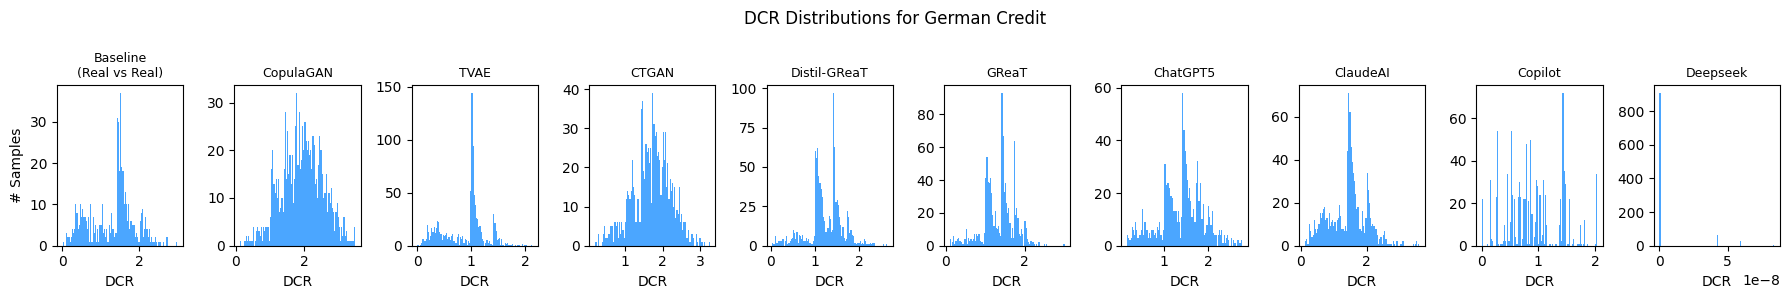

In [ ]:
# Calcolo DCR per ogni modello generativo
dcr_results = {
    "Baseline\n(Real vs Real)": dcr_baseline_german,
    "CopulaGAN": compute_dcr(X_german, X_german_CopulaGAN),
    "TVAE": compute_dcr(X_german, X_german_TVAE),
    "CTGAN": compute_dcr(X_german, X_german_CTGAN),
    "Distil-GReaT": compute_dcr(X_german, X_german_distil_GReaT),
    "GReaT": compute_dcr(X_german, X_german_GReaT),
    "ChatGPT5": compute_dcr(X_german, X_german_GPT5),
    "ClaudeAI": compute_dcr(X_german, X_german_Sonnet4_5),
    "Copilot": compute_dcr(X_german, X_german_Copilot),
    "Deepseek": compute_dcr(X_german, X_german_Deepseek),
}

fig, axes = plt.subplots(1, len(dcr_results), figsize=(18, 3), sharey=False)
fig.suptitle("DCR Distributions for German Credit", fontsize=12)

for ax, (model_name, dcr_values) in zip(axes, dcr_results.items()):
    ax.hist(dcr_values, bins=100, color="dodgerblue", alpha=0.8)
    ax.set_title(model_name, fontsize=9)
    ax.set_xlabel("DCR")
    if ax == axes[0]:
        ax.set_ylabel("# Samples")

plt.tight_layout()
plt.show()

#### Australian Credit

In [ ]:
X_australian_train, X_australian_test = train_test_split(X_australian, test_size=0.5, random_state=42)
dcr_baseline_australian = compute_dcr(X_australian_train, X_australian_test)

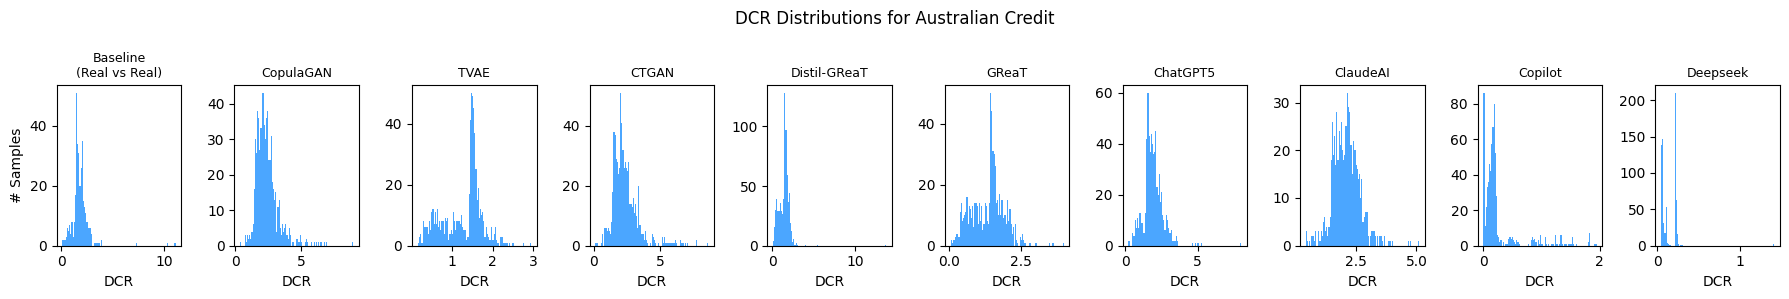

In [ ]:
# Calcolo DCR per ogni modello generativo
dcr_results_australian = {
    "Baseline\n(Real vs Real)": dcr_baseline_australian,
    "CopulaGAN": compute_dcr(X_australian, X_australian_CopulaGAN),
    "TVAE": compute_dcr(X_australian, X_australian_TVAE),
    "CTGAN": compute_dcr(X_australian, X_australian_CTGAN),
    "Distil-GReaT": compute_dcr(X_australian, X_australian_distil_GReaT),
    "GReaT": compute_dcr(X_australian, X_australian_GReaT),
    "ChatGPT5": compute_dcr(X_australian, X_australian_GPT5),
    "ClaudeAI": compute_dcr(X_australian, X_australian_Sonnet4_5),
    "Copilot": compute_dcr(X_australian, X_australian_Copilot),
    "Deepseek": compute_dcr(X_australian, X_australian_Deepseek),
}

# Plot degli istogrammi
fig, axes = plt.subplots(1, len(dcr_results_australian), figsize=(18, 3), sharey=False)
fig.suptitle("DCR Distributions for Australian Credit", fontsize=12)

for ax, (model_name, dcr_values) in zip(axes, dcr_results_australian.items()):
    ax.hist(dcr_values, bins=100, color="dodgerblue", alpha=0.8)
    ax.set_title(model_name, fontsize=9)
    ax.set_xlabel("DCR")
    if ax == axes[0]:
        ax.set_ylabel("# Samples")

plt.tight_layout()
plt.show()

The DCR (Distance to Closest Record) distributions provide crucial insight into the similarity between real and synthetic samples, as well as potential privacy risks, by measuring the Euclidean distance from each synthetic record to its nearest neighbor in the real dataset. The baseline (Real vs. Real) distribution represents the expected reference behavior under natural sampling variance, serving as a benchmark for optimal distributional overlap.

German Credit Dataset

For the German Credit dataset, a detailed inspection of the DCR profiles reveals distinct behavioral groupings among the generative architectures.

First, the GAN-based models (CopulaGAN and CTGAN) produce noticeably wider, smoother, and almost Gaussian-like distributions compared to the multi-modal and spiky baseline. This indicates that these models learn a smoothed, continuous approximation of the feature space, thereby failing to capture the sharp, localized density clusters present in the real data. Furthermore, CopulaGAN's distribution is visibly right-shifted, confirming its struggle to map the complex dependencies of this mixed-type dataset.

Second, a clear pattern emerges among several LLM-based generators. Distil-GReaT, GReaT, and ChatGPT-5 exhibit strikingly similar DCR profiles. While they effectively replicate the general multi-modal shape of the baseline, all three are characterized by the introduction of a pronounced secondary peak at a distance of approximately 1. This shared distributional artifact suggests that representing tabular data as sequential tokens inherently biases these models to cluster a subset of synthetic samples at specific, fixed structural distances from the original records. TVAE and ClaudeAI, on the other hand, more closely mirror the primary peak structure of the baseline without this distinct secondary clustering.

 Copilot produces a highly irregular, comb-like distribution with sharp spikes at specific distance intervals, suggesting generation artifacts where the model collapses onto discrete, grid-like regions of the feature space. Most critically, the Deepseek distribution collapses entirely into a massive spike near zero. While the plot shows microscopic secondary peaks, the axis scale (1e-8) indicates these distances are effectively zero, representing mere floating-point precision artifacts. This definitively resolves previous statistical anomalies: Deepseek did not generate novel samples, but engaged in near-perfect data memorization, effectively replicating the training records.

Australian Credit Dataset

For the Australian Credit dataset, the majority of generative models produce DCR distributions that closely follow the baseline. The predominantly numerical structure of this dataset, with categorical variables already encoded, simplifies the modeling of continuous feature spaces and reduces the risk of large distributional gaps.

An apparent visual exception is Distil-GReaT, whose histogram appears significantly taller. Importantly, this effect is not due to a larger number of samples, but rather to differences in how distances are concentrated across bins. Distil-GReaT produces synthetic samples whose nearest-neighbor distances are highly concentrated in a narrow range, resulting in taller histogram bars despite an identical sample count. This reflects a lower variance in DCR values rather than an increased data volume.

Finally, both Copilot and Deepseek exhibit concerning DCR profiles on the Australian dataset. While they do not show the exact zero-distance replication seen with Deepseek on the German dataset, their distributions are heavily left-skewed, peaking much closer to zero than the established baseline. This indicates that while they are generating technically novel records, these synthetic samples are dangerously proximal to the original data points. Such behavior suggests a strong tendency toward overfitting or partial memorization, highlighting significant privacy vulnerabilities even when predictive utility appears high.

## 6 Conclusion

Taken together, the results across predictive accuracy, discriminator-based evaluation, and DCR analysis indicate that no single generative model universally dominates across all settings. However, clear patterns emerge when these metrics are considered jointly, particularly highlighting the profound impact of generation methodologies when utilizing foundational Large Language Models (LLMs) for tabular data synthesis.

The Impact of LLM Generation Methodology
A critical distinction in this comparative analysis lies in the operational approach required to extract data from different foundational LLMs. For ChatGPT-5 and ClaudeAI, the generation process natively supported direct CSV file outputs. In contrast, Copilot and Deepseek imposed interface constraints that required the iterative generation of raw text blocks, which were subsequently parsed. This operational divergence introduced a significant structural variance into the generated datasets. Models restricted to chunked text-block generation exhibited severe pathological behaviors: Deepseek demonstrated catastrophic data memorization on the German Credit dataset (as confirmed by DCR values collapsing to zero), while Copilot produced highly detectable, grid-like distributional anomalies. These failures suggest that piecemeal text generation disrupts the models' ability to maintain a continuous approximation of the tabular distribution, forcing them into exact replication or unnatural repetitive patterns.

Operational Constraints and Prompting Limitations
Beyond the interface constraints of CSV versus text-block generation, the broader landscape of foundational models presented significant operational hurdles. It should be noted that several other LLMs were tested during the preliminary phases of this research; however, they were excluded from the final analysis because they either failed to produce structurally acceptable tabular data or encountered execution errors when processing the generation constraints.
Furthermore, it is crucial to contextualize the performance of the evaluated LLMs within the bounds of the applied prompt engineering. The data synthesis for models like ChatGPT-5, ClaudeAI, Copilot, and Deepseek relied on relatively simple, zero-shot or few-shot instructions, typically involving only one or two conversational turns. The prompts were not heavily engineered or optimized for complex tabular constraints. Consequently, it is highly plausible that employing more sophisticated prompt engineering strategies—such as iterative refinement, detailed schema enforcement, or advanced in-context learning—could significantly mitigate the observed artifacts and further enhance the distributional fidelity and utility of LLM-generated synthetic data.

Consistency and Model Trade-offs
Among the successfully evaluated models, ChatGPT-5 provided the most consistent trade-off between predictive utility and distributional similarity across both datasets. It achieved high downstream classification performance while remaining relatively difficult to distinguish from real data, effectively preserving decision-relevant structures without easily detectable artifacts. ClaudeAI, despite sharing the CSV generation advantage, displayed unstable behavior, performing moderately on the German Credit dataset but failing to reproduce the statistical structure of the Australian data.

Fine-tuned LLMs and Traditional Models
The performance of GReaT—an LLM explicitly fine-tuned for tabular data—proved strongly dataset-dependent. On the numerical Australian dataset, GReaT demonstrated competitive accuracy and excellent distributional alignment. However, on the German dataset, its performance degraded due to out-of-context textual concatenations, highlighting the ongoing challenges LLM-based approaches face with semantically rich categorical features. Finally, traditional tabular generative models demonstrated mixed to poor behavior. While TVAE often yielded reasonable predictive performance, it remained highly recognizable under discriminator evaluation. GAN-based models (CopulaGAN and CTGAN) consistently struggled across metrics, producing synthetic data that were both easily distinguishable and less useful for downstream predictive tasks.

Final Summary
In summary, these findings emphasize that synthetic data quality cannot be evaluated through predictive accuracy alone; it must be assessed through multiple complementary criteria, including rigorous privacy and distance metrics. While foundational LLMs represent highly capable tools for synthetic generation, their current out-of-the-box effectiveness is heavily bottlenecked by dataset structure, user interaction methodology, and interface constraints. Dedicated tabular generators still require substantial improvements in handling mixed-type data, but LLMs—especially when provided with appropriate structural constraints and direct file generation—emerge as highly competitive alternatives that warrant further exploration through advanced prompting techniques.